NAME: ALOK KUMAR MAVI, SEC: B (CU240251681)

#LAB SHEET - 07

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

OpenCV version: 5.0.0
NumPy version: 2.1.3


In [2]:
from google.colab import files

uploaded = files.upload()

Saving video.mp4 to video.mp4


In [3]:
video_path = "video.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open the video.")
else:
    print("Video opened successfully!")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print("FPS:", fps)
    print("Total Frames:", frame_count)
    print("Resolution:", width, "x", height)

cap.release()

Video opened successfully!
FPS: 30.0
Total Frames: 60
Resolution: 2560 x 1440


In [4]:
cap = cv2.VideoCapture(video_path)

ret1, frame1 = cap.read()
ret2, frame2 = cap.read()

cap.release()

if ret1 and ret2:
    print("Two consecutive frames successfully read.")
else:
    print("Error reading frames.")

Two consecutive frames successfully read.


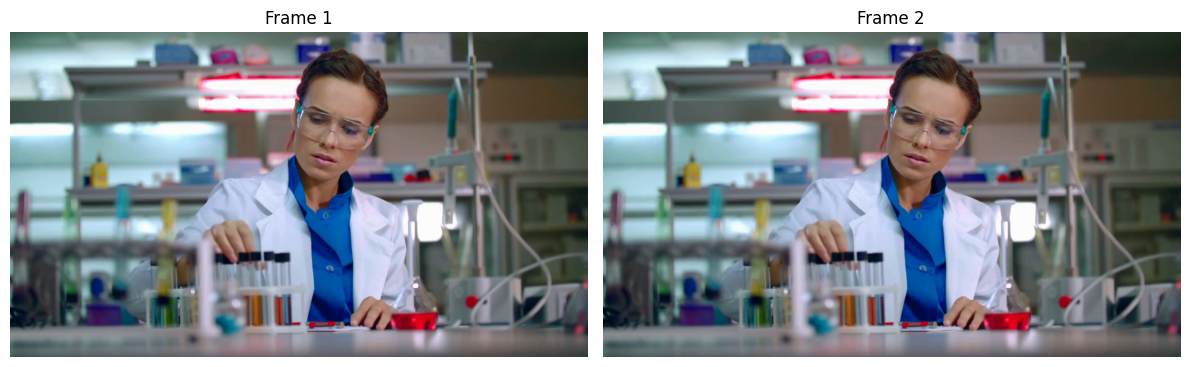

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
plt.title("Frame 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
plt.title("Frame 2")
plt.axis("off")

plt.tight_layout()
plt.show()

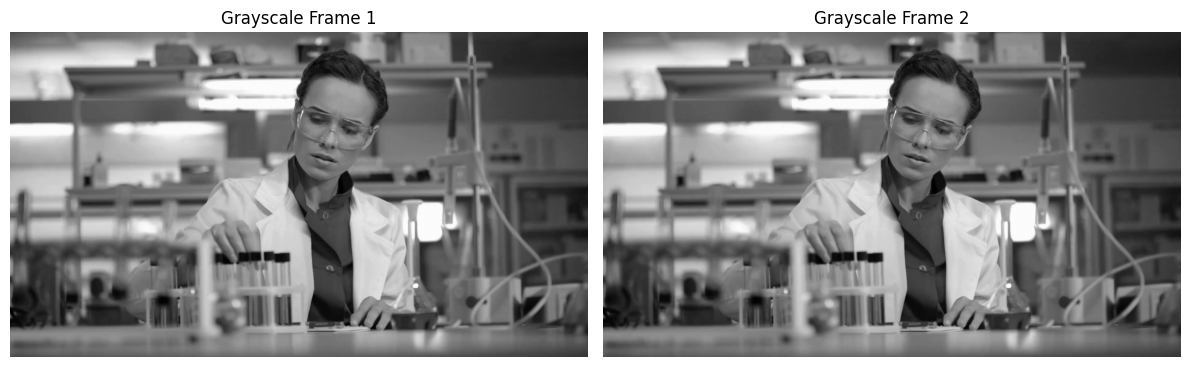

In [6]:
gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray1, cmap="gray")
plt.title("Grayscale Frame 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray2, cmap="gray")
plt.title("Grayscale Frame 2")
plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Detect good feature points in the first grayscale frame

feature_params = dict(
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

p0 = cv2.goodFeaturesToTrack(gray1, mask=None, **feature_params)

print("Number of detected feature points:", len(p0))

Number of detected feature points: 30


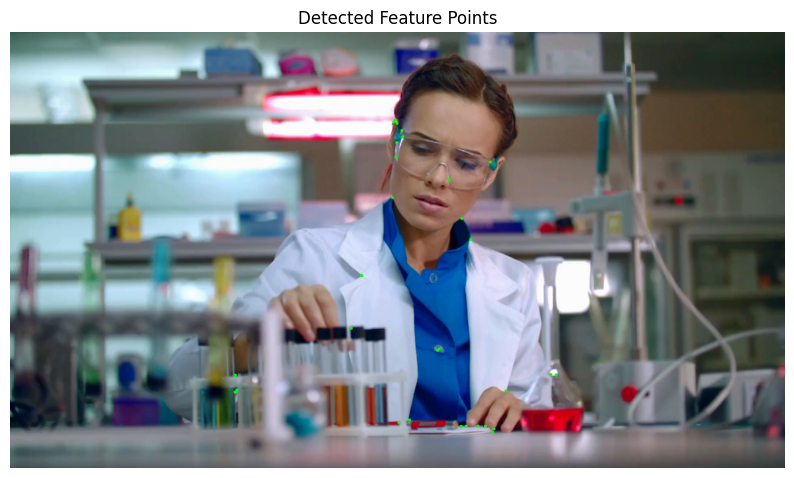

In [8]:
feature_frame = frame1.copy()

for point in p0:
    x, y = point.ravel()
    cv2.circle(feature_frame, (int(x), int(y)), 5, (0, 255, 0), -1)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(feature_frame, cv2.COLOR_BGR2RGB))
plt.title("Detected Feature Points")
plt.axis("off")
plt.show()

In [9]:
# Parameters for Lucas-Kanade Optical Flow

lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(
        cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
        10,
        0.03
    )
)

# Calculate optical flow
p1, status, error = cv2.calcOpticalFlowPyrLK(
    gray1,
    gray2,
    p0,
    None,
    **lk_params
)

# Select only successfully tracked points
good_new = p1[status == 1]
good_old = p0[status == 1]

print("Successfully tracked points:", len(good_new))

Successfully tracked points: 30


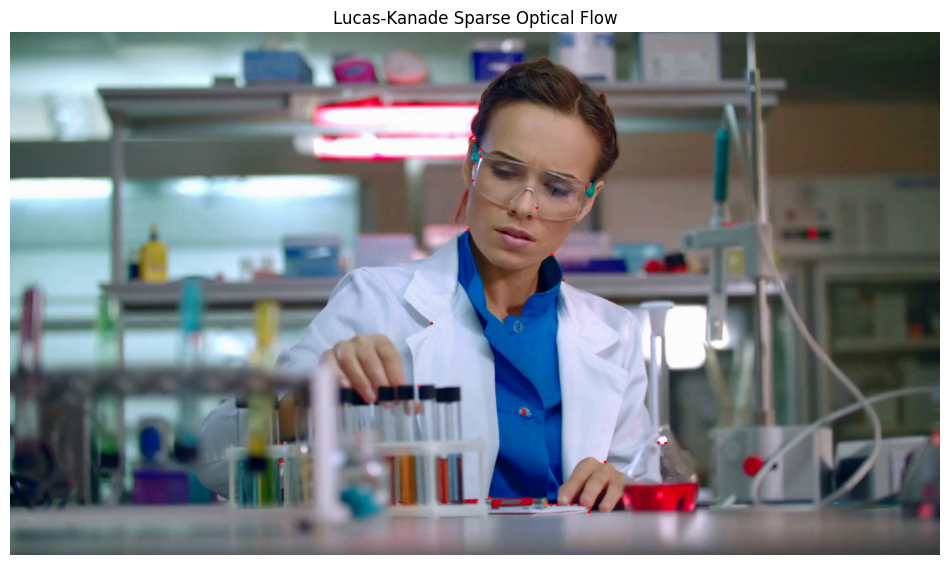

In [10]:
lk_result = frame2.copy()

for new, old in zip(good_new, good_old):
    x_new, y_new = new.ravel()
    x_old, y_old = old.ravel()

    # Draw motion arrow
    cv2.arrowedLine(
        lk_result,
        (int(x_old), int(y_old)),
        (int(x_new), int(y_new)),
        (0, 255, 0),
        2,
        tipLength=0.3
    )

    # Draw current point
    cv2.circle(
        lk_result,
        (int(x_new), int(y_new)),
        4,
        (0, 0, 255),
        -1
    )

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(lk_result, cv2.COLOR_BGR2RGB))
plt.title("Lucas-Kanade Sparse Optical Flow")
plt.axis("off")
plt.show()

In [11]:
displacements = good_new - good_old

magnitude = np.sqrt(
    displacements[:, 0]**2 +
    displacements[:, 1]**2
)

print("Average motion magnitude:", np.mean(magnitude))
print("Maximum motion magnitude:", np.max(magnitude))
print("Minimum motion magnitude:", np.min(magnitude))

Average motion magnitude: 0.030686509
Maximum motion magnitude: 0.21283312
Minimum motion magnitude: 0.0


In [12]:
# Calculate Farneback Dense Optical Flow

flow = cv2.calcOpticalFlowFarneback(
    gray1,
    gray2,
    None,
    pyr_scale=0.5,
    levels=3,
    winsize=15,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0
)

print("Dense optical flow calculated successfully.")
print("Flow shape:", flow.shape)

Dense optical flow calculated successfully.
Flow shape: (1440, 2560, 2)


In [13]:
magnitude, angle = cv2.cartToPolar(
    flow[..., 0],
    flow[..., 1]
)

print("Average motion magnitude:", np.mean(magnitude))
print("Maximum motion magnitude:", np.max(magnitude))

Average motion magnitude: 0.03133031
Maximum motion magnitude: 4.395469


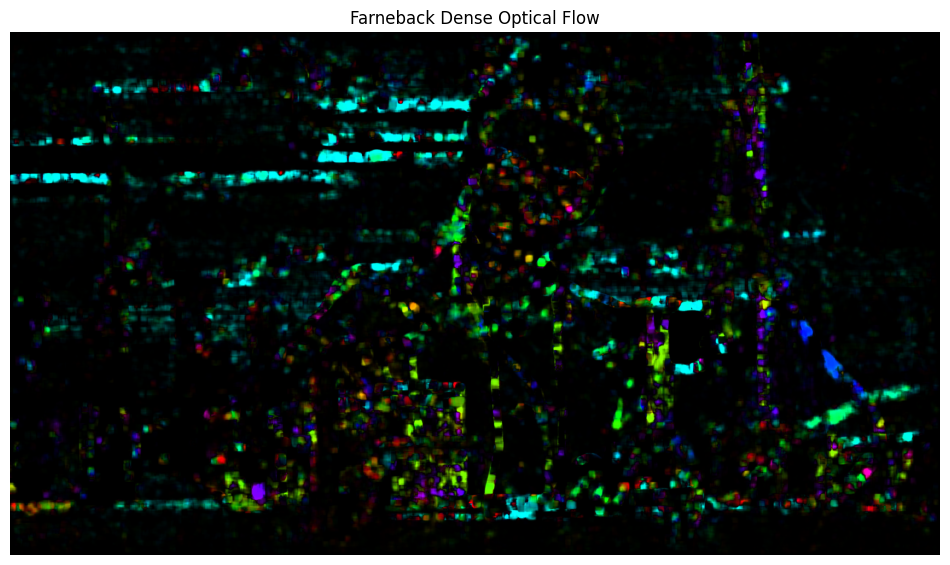

In [14]:
# Improved Farneback Dense Optical Flow Visualization

mag, ang = cv2.cartToPolar(
    flow[..., 0],
    flow[..., 1]
)

hsv = np.zeros((gray1.shape[0], gray1.shape[1], 3), dtype=np.uint8)

hsv[..., 0] = (ang * 180 / np.pi / 2).astype(np.uint8)
hsv[..., 1] = 255

max_mag = np.percentile(mag, 99)

if max_mag > 0:
    hsv[..., 2] = np.clip(
        (mag / max_mag) * 255,
        0,
        255
    ).astype(np.uint8)

flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(flow_rgb)
plt.title("Farneback Dense Optical Flow")
plt.axis("off")
plt.show()

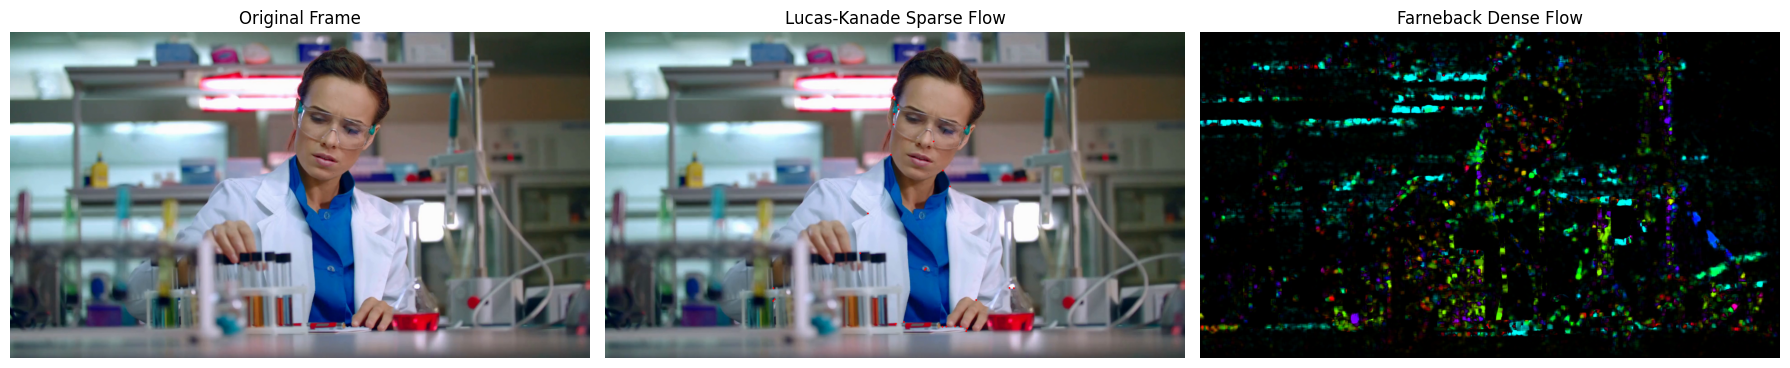

In [15]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
plt.title("Original Frame")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(lk_result, cv2.COLOR_BGR2RGB))
plt.title("Lucas-Kanade Sparse Flow")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(flow_rgb)
plt.title("Farneback Dense Flow")
plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Process multiple consecutive frames

cap = cv2.VideoCapture(video_path)

ret, previous_frame = cap.read()

if not ret:
    print("Error: Could not read the video.")
else:
    previous_gray = cv2.cvtColor(previous_frame, cv2.COLOR_BGR2GRAY)

    frame_number = 1
    motion_values = []

    while frame_number <= 30:
        ret, current_frame = cap.read()

        if not ret:
            break

        current_gray = cv2.cvtColor(current_frame, cv2.COLOR_BGR2GRAY)

        # Farneback dense optical flow
        flow = cv2.calcOpticalFlowFarneback(
            previous_gray,
            current_gray,
            None,
            pyr_scale=0.5,
            levels=3,
            winsize=15,
            iterations=3,
            poly_n=5,
            poly_sigma=1.2,
            flags=0
        )

        # Calculate motion magnitude
        magnitude, angle = cv2.cartToPolar(
            flow[..., 0],
            flow[..., 1]
        )

        average_motion = np.mean(magnitude)
        motion_values.append(average_motion)

        previous_gray = current_gray
        frame_number += 1

    cap.release()

    print("Frames processed:", len(motion_values))
    print("Average motion across frames:", np.mean(motion_values))

Frames processed: 30
Average motion across frames: 0.21341477


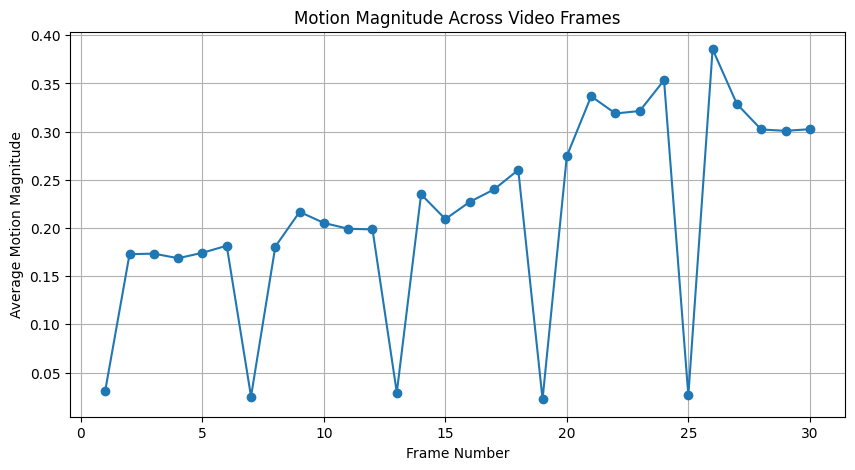

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(motion_values) + 1),
    motion_values,
    marker="o"
)

plt.title("Motion Magnitude Across Video Frames")
plt.xlabel("Frame Number")
plt.ylabel("Average Motion Magnitude")
plt.grid(True)

plt.show()

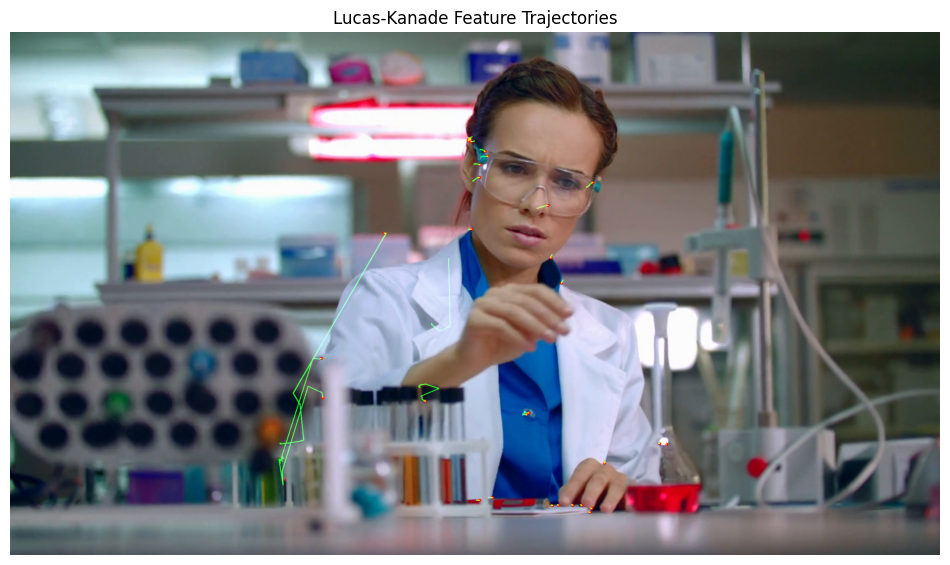

In [18]:
# Lucas-Kanade feature tracking across multiple frames

cap = cv2.VideoCapture(video_path)

ret, old_frame = cap.read()

if not ret:
    print("Error: Could not read video.")
else:
    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

    feature_params = dict(
        maxCorners=100,
        qualityLevel=0.3,
        minDistance=7,
        blockSize=7
    )

    p0 = cv2.goodFeaturesToTrack(
        old_gray,
        mask=None,
        **feature_params
    )

    # Create a mask for drawing trajectories
    mask = np.zeros_like(old_frame)

    frame_number = 0

    while frame_number < 30:
        ret, frame = cap.read()

        if not ret:
            break

        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        p1, status, error = cv2.calcOpticalFlowPyrLK(
            old_gray,
            frame_gray,
            p0,
            None,
            **lk_params
        )

        if p1 is None:
            break

        good_new = p1[status == 1]
        good_old = p0[status == 1]

        for new, old in zip(good_new, good_old):
            x_new, y_new = new.ravel()
            x_old, y_old = old.ravel()

            mask = cv2.line(
                mask,
                (int(x_new), int(y_new)),
                (int(x_old), int(y_old)),
                (0, 255, 0),
                2
            )

            frame = cv2.circle(
                frame,
                (int(x_new), int(y_new)),
                4,
                (0, 0, 255),
                -1
            )

        output = cv2.add(frame, mask)

        # Display the first processed result
        if frame_number == 29:
            plt.figure(figsize=(12, 7))
            plt.imshow(
                cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
            )
            plt.title("Lucas-Kanade Feature Trajectories")
            plt.axis("off")
            plt.show()

        old_gray = frame_gray.copy()
        p0 = good_new.reshape(-1, 1, 2)

        if len(p0) == 0:
            break

        frame_number += 1

    cap.release()

In [19]:
comparison = {
    "Property": [
        "Type",
        "Motion Estimation",
        "Computational Complexity",
        "Number of Points",
        "Output",
        "Typical Use"
    ],
    "Lucas-Kanade": [
        "Sparse",
        "Selected feature points",
        "Lower",
        "Limited feature points",
        "Motion vectors / trajectories",
        "Object tracking"
    ],
    "Farneback": [
        "Dense",
        "Every pixel",
        "Higher",
        "All pixels",
        "Dense motion field",
        "Motion analysis / navigation"
    ]
}

for key, values in comparison.items():
    print(f"{key:<25} | {values[0]:<25} | {values[1]}")

Property                  | Type                      | Motion Estimation
Lucas-Kanade              | Sparse                    | Selected feature points
Farneback                 | Dense                     | Every pixel


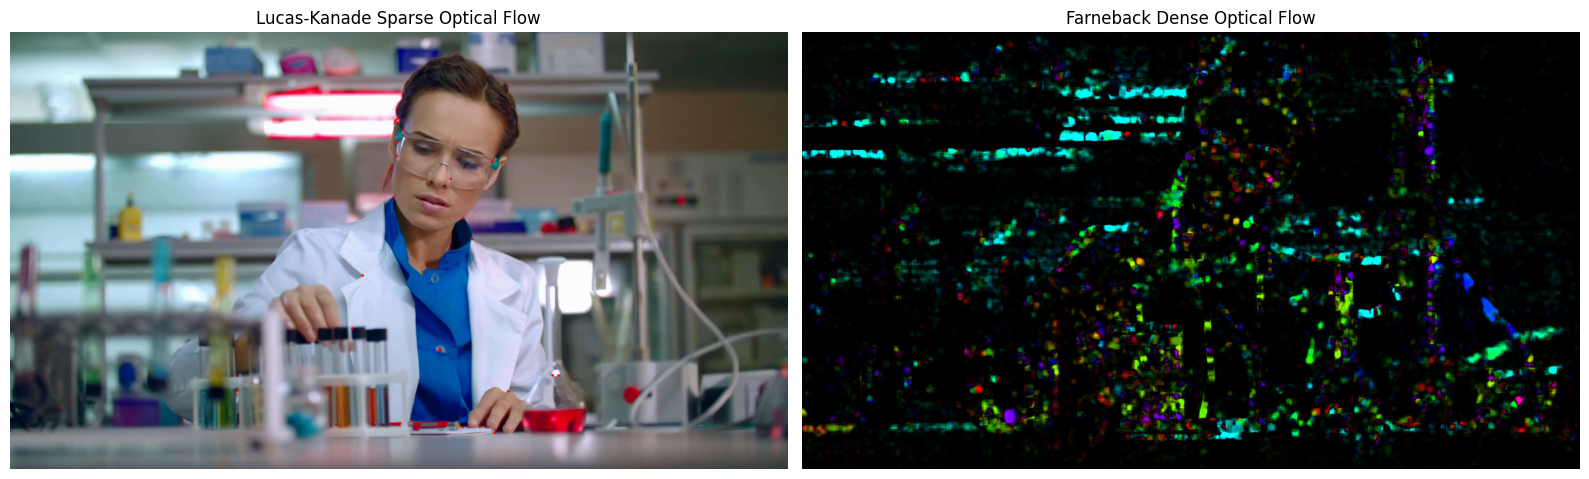

In [20]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(lk_result, cv2.COLOR_BGR2RGB))
plt.title("Lucas-Kanade Sparse Optical Flow")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(flow_rgb)
plt.title("Farneback Dense Optical Flow")
plt.axis("off")

plt.tight_layout()
plt.show()

NAME: ALOK KUMAR MAVI, SEC: B (CU240251681)

## Experiment No. 7 — Motion Estimation Using Optical Flow Algorithms

### 1. What is Optical Flow? How is it used in computer vision?

**Answer:**
Optical Flow is the apparent motion of objects, surfaces, or the camera between consecutive video frames. It is used in computer vision to estimate the direction and speed of motion and to understand dynamic scenes. It is useful in applications such as object tracking, surveillance, robotics, autonomous driving, and action recognition.

---

### 2. Explain the working principle of the Lucas-Kanade Optical Flow algorithm.

**Answer:**
The Lucas-Kanade algorithm is a **Sparse Optical Flow** method that tracks selected feature points between consecutive frames. It assumes that the motion of a small group of neighboring pixels is similar. Image gradients are used to estimate the displacement of these feature points, and the resulting motion vectors indicate how the points have moved from one frame to the next.

---

### 3. What is Dense Optical Flow? How does it differ from Sparse Optical Flow?

**Answer:**
Dense Optical Flow estimates motion for **every pixel** in an image. In contrast, Sparse Optical Flow estimates motion only for selected feature points.

Dense Optical Flow provides a complete motion field and is useful for detailed motion analysis, while Sparse Optical Flow is computationally simpler and is commonly used for tracking important features or objects.

---

### 4. Compare the Lucas-Kanade and Farneback optical flow algorithms.

**Answer:**

| Feature                  | Lucas-Kanade                    | Farneback                |
| ------------------------ | ------------------------------- | ------------------------ |
| Type                     | Sparse Optical Flow             | Dense Optical Flow       |
| Motion estimation        | Selected feature points         | Every pixel              |
| Computational complexity | Lower                           | Higher                   |
| Output                   | Motion vectors and trajectories | Dense motion field       |
| Typical use              | Feature/object tracking         | Detailed motion analysis |

Lucas-Kanade is generally faster because it tracks only selected points, while Farneback provides more complete motion information but requires more computation.

---

### 5. What assumptions are made while computing optical flow?

**Answer:**
Optical flow calculations generally assume that the **brightness of an object remains approximately constant** between consecutive frames. They also assume that motion between frames is relatively small and that neighboring pixels have similar motion. These assumptions allow the motion of image features to be estimated from changes between frames.

---

### 6. What factors can affect the accuracy of optical flow estimation?

**Answer:**
The accuracy of optical flow can be affected by:

* High object speed or large displacement between frames.
* Changes in lighting or brightness.
* Camera motion.
* Motion blur and image noise.
* Occlusion of objects.
* Low-texture or uniform regions.
* Sudden changes in the scene.

These factors can make it difficult to correctly estimate the movement between frames.

---

### 7. Mention five real-world applications of optical flow in computer vision.

**Answer:**

1. Autonomous driving and navigation.
2. Video surveillance.
3. Object tracking.
4. Gesture and action recognition.
5. Robotics and motion analysis.

Optical flow is useful wherever understanding movement in video is important.

---

### 8. Why are grayscale images generally used for optical flow computation?

**Answer:**
Grayscale images are generally used because optical flow primarily relies on **intensity changes and image gradients** rather than color information. Converting images to grayscale reduces computational complexity and simplifies the motion-estimation process while retaining the important brightness information needed for optical flow.

---

### 9. What are the limitations of optical flow algorithms in real-world environments?

**Answer:**
Optical flow algorithms can have difficulty when there are rapid movements, motion blur, lighting changes, occlusions, camera movement, noise, or areas with little visual texture. They may also produce inaccurate motion estimates when the assumptions of constant brightness and small motion are violated.

---

### 10. How does optical flow contribute to applications such as autonomous driving, video surveillance, and action recognition?

**Answer:**
In **autonomous driving**, optical flow helps detect the movement of vehicles, pedestrians, and other objects and assists in understanding the surrounding scene. In **video surveillance**, it can identify moving objects and unusual motion patterns. In **action recognition**, optical flow captures the movement of body parts and objects across video frames, helping distinguish different actions and activities.
